In [1]:
# AI Research Scientist Blueprint 2025
### By MD Dilkash Reza
### Data Source: Global AI Job Market 2025 (Kaggle)
##"I analysed 15,000 AI job postings and built a data-driven career roadmap for myself."

In [11]:
# section 1: load and explore
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# load data
df = pd.read_csv(r"C:\Users\dilka\Downloads\archive (1)\ai_job_dataset.csv")

In [4]:
#Basic exploration
print("Shape", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst look:")
df.head()

Shape (15000, 19)

Columns: ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']

Missing values:
 job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

First look:


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [6]:
## Section 2: Filter AI Research Scientist Roles
# filter only Ai Research Scientist role
ai_scientist = df[df["job_title"] == "AI Research Scientist"].copy()

print("Total AI Research Scientist jobs:", len(ai_scientist))
print("\nExperience levels:")
print(ai_scientist["experience_level"].value_counts())
print("\nEmployment types:")
print(ai_scientist["employment_type"].value_counts())

Total AI Research Scientist jobs: 756

Experience levels:
experience_level
EX    201
EN    187
MI    186
SE    182
Name: count, dtype: int64

Employment types:
employment_type
FL    197
CT    191
FT    189
PT    179
Name: count, dtype: int64


In [7]:
# Section 3: Salary Analysis

#Salary statistics
print("Average Salary:", round(ai_scientist["salary_usd"].mean(), 2))
print("Median Salary:", round(ai_scientist["salary_usd"].median(), 2))
print("Minimum Salary:", round(ai_scientist["salary_usd"].min(), 2))
print("Maximum Salary:", round(ai_scientist["salary_usd"].max(), 2))


#Salary by experience level
print("\nAverage Salary by Experience:")
print(ai_scientist.groupby("experience_level")["salary_usd"].mean().sort_values(ascending=False).round(2))

Average Salary: 117897.93
Median Salary: 100990.0
Minimum Salary: 33092
Maximum Salary: 394917

Average Salary by Experience:
experience_level
EX    194112.36
SE    120548.93
MI     90090.90
EN     61055.80
Name: salary_usd, dtype: float64


C:\Users\dilka\AppData\Local\Temp\ipykernel_25424\167384007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exp_sal.index, y=exp_sal.values,


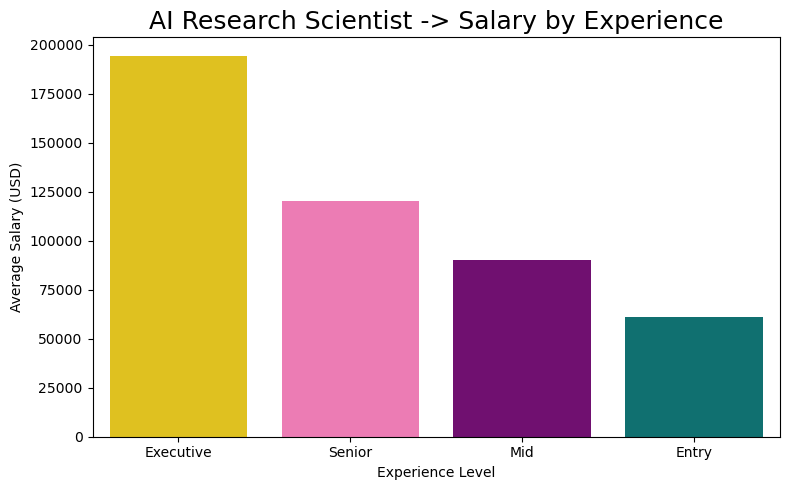

In [12]:
# Visualise salary by experience
exp_sal = ai_scientist.groupby("experience_level")["salary_usd"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=exp_sal.index, y=exp_sal.values,
            palette=["gold", "hotpink", "purple", "teal"])
plt.title("AI Research Scientist -> Salary by Experience", fontsize=18)
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.xticks(ticks=[0,1,2,3], labels=["Executive", "Senior", "Mid", "Entry"])
plt.tight_layout()
plt.show()

In [ ]:
## Section 4: Most Required Skills

required_skills
Python        236
Kubernetes    164
SQL           163
PyTorch       147
Scala         144
Linux         140
TensorFlow    138
GCP           134
Java          132
Git           126
Name: count, dtype: int64


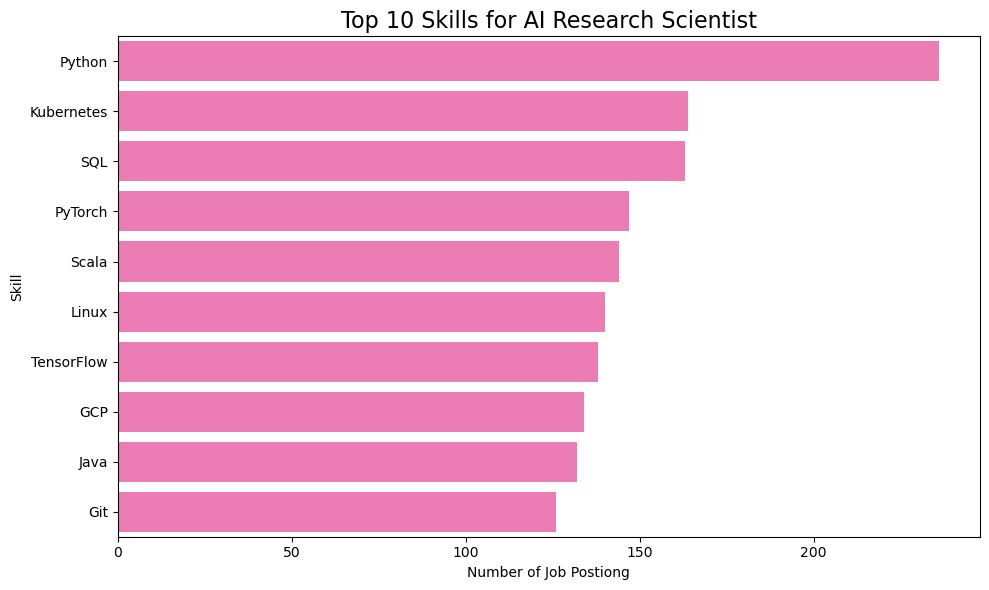

In [15]:
# split skills and count individually
all_skills = ai_scientist["required_skills"].str.split(", ").explode()
top_skills = all_skills.value_counts().head(10)

print(top_skills)

#Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, color="hotpink")
plt.title("Top 10 Skills for AI Research Scientist", fontsize=16)
plt.xlabel("Number of Job Postiong")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [16]:
## Section 5: Best Countries for AI Research Scientists

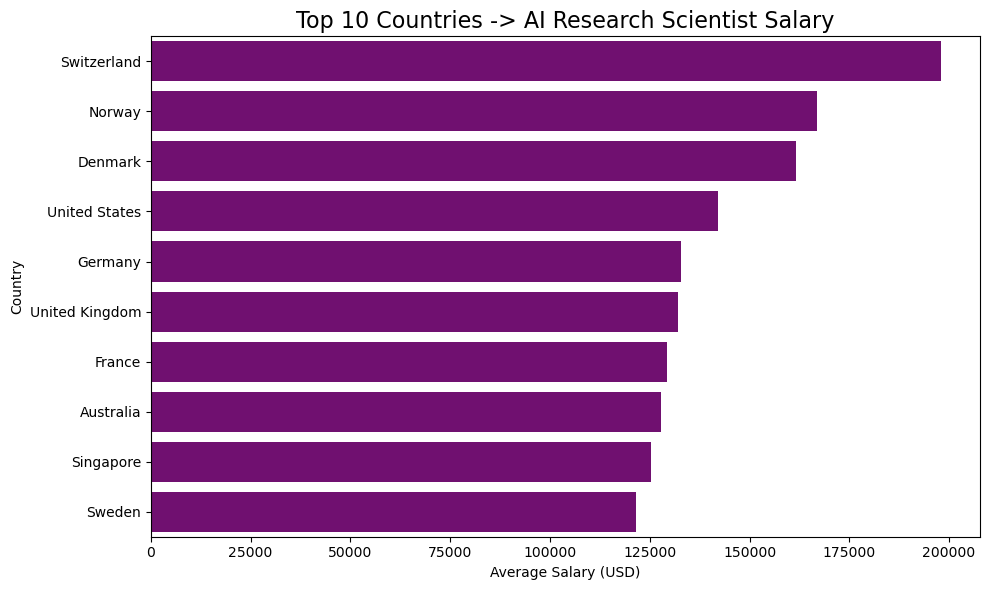

In [17]:
#Top 10 locations by average salary
location = ai_scientist.groupby("company_location")["salary_usd"].mean().sort_values(ascending=False).head(10)

#Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=location.values, y=location.index, color="purple")
plt.title("Top 10 Countries -> AI Research Scientist Salary", fontsize=16)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [18]:
## Section 6: Personal Roadmap — What It Takes

## Key Findings

1. **756 AI Research Scientist jobs** exist globally in 2025
2. **Entry level salary: $61,055** — senior reaches $194,112
3. **Python is #1 skill** — required in 236/756 job postings
4. **Switzerland pays the most** — $200K average
5. **Entry level positions exist** — you don't need 10 years experience
6. **Freelance is most common** — 197 out of 756 jobs

## My Personal Action Plan

| Timeline | Goal |
|---|---|
| Now | Master Python + pandas |
| 3 months | Learn SQL + Git |
| 6 months | Learn PyTorch + TensorFlow |
| 12 months | Build ML project on GitHub |
| 18 months | Apply for Entry level roles |
| 5 years | Target Switzerland or Germany |